In [1]:
# ==========================================
# SEMANA 1: PREPARACIÓN Y LIMPIEZA DE DATOS
# Caso de Estudio: Sensores del Puente
# ==========================================

In [2]:
# 1. IMPORTACIÓN DE LIBRERÍAS (TOOLKIT)
# ------------------------------------------
# Pandas: El "Excel" de Python. Maneja tablas de datos (DataFrames).
import pandas as pd
# NumPy: Para operaciones numéricas básicas y manejo de NaN.
import numpy as np
# Matplotlib/Seaborn: Para visualizar qué está pasando.
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuración visual para gráficos profesionales
sns.set_theme(style="whitegrid")

In [4]:
# ==========================================
# 2. GENERACIÓN DE DATOS (Simulación del Problema)
# ==========================================

In [5]:
# NOTA DOCENTE: Creamos un archivo CSV sucio "al vuelo" para el ejercicio.
# En la vida real, este archivo vendría del sistema SCADA del puente.


In [6]:
raw_data = {
    'Fecha': ['01/01/2024 08:00', '01/01/2024 09:00', '2024-01-01 10:00:00', 'Error_Date', '01/01/2024 12:00', '01/01/2024 13:00'],
    'Sensor_Deformacion_uStrain': ['120.5', '122.1', '10000.0', 'No_Data', '119.8', '121.2'], # Nota el outlier 10000 y el texto
    'Temperatura_C': [25.1, 26.5, np.nan, 28.0, 29.1, 150.0] # Nota el NaN y el outlier físico (150°C es imposible en el puente)
}

In [7]:
# Guardamos esto como un archivo real para simular la carga
df_sucio = pd.DataFrame(raw_data)
df_sucio.to_csv('datos_puente_raw.csv', index=False)

print("¡Archivo 'datos_puente_raw.csv' generado con éxito! (Contiene errores intencionales)")


¡Archivo 'datos_puente_raw.csv' generado con éxito! (Contiene errores intencionales)


In [8]:
# ==========================================
# 3. INGESTIÓN Y PRIMERA INSPECCIÓN
# ==========================================

In [9]:
# Cargamos el archivo tal cual
df = pd.read_csv('datos_puente_raw.csv')

In [10]:
print("\n--- VISTA PREVIA DE LOS DATOS CRUDOS ---")
display(df)

print("\n--- INFORMACIÓN TÉCNICA (Tipos de Datos) ---")
# .info() es vital: nos dice qué cree Python que son los datos.
# Observa que 'Sensor_Deformacion' aparece como 'object' (texto) y no 'float' (número).
df.info()


--- VISTA PREVIA DE LOS DATOS CRUDOS ---


,Fecha,Sensor_Deformacion_uStrain,Temperatura_C
0,01/01/2024 08:00,120.5,25.1
1,01/01/2024 09:00,122.1,26.5
2,2024-01-01 10:00:00,10000.0,NaN
3,Error_Date,No_Data,28.0
4,01/01/2024 12:00,119.8,29.1
5,01/01/2024 13:00,121.2,150.0



--- INFORMACIÓN TÉCNICA (Tipos de Datos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       6 non-null      object 
 1   Sensor_Deformacion_uStrain  6 non-null      object 
 2   Temperatura_C               5 non-null      float64
dtypes: float64(1), object(2)
memory usage: 272.0+ bytes


In [11]:
# ==========================================
# 4. LIMPIEZA DE DATOS (DATA WRANGLING)
# ==========================================


In [12]:
print("\n--- INICIANDO PROTOCOLO DE LIMPIEZA ---")


--- INICIANDO PROTOCOLO DE LIMPIEZA ---


In [13]:
# PASO A: Limpieza de Fechas
# 'coerce' transforma lo que no entienda en NaT (Not a Time)
df['Fecha_Clean'] = pd.to_datetime(df['Fecha'], errors='coerce')
display(df)

,Fecha,Sensor_Deformacion_uStrain,Temperatura_C,Fecha_Clean
0,01/01/2024 08:00,120.5,25.1,2024-01-01 08:00:00
1,01/01/2024 09:00,122.1,26.5,2024-01-01 09:00:00
2,2024-01-01 10:00:00,10000.0,NaN,NaT
3,Error_Date,No_Data,28.0,NaT
4,01/01/2024 12:00,119.8,29.1,2024-01-01 12:00:00
5,01/01/2024 13:00,121.2,150.0,2024-01-01 13:00:00


In [14]:
# PASO B: Limpieza Numérica (Sensor de Deformación)
# Convertimos texto a números. 'coerce' transforma "No_Data" en NaN.
df['Deformacion_Clean'] = pd.to_numeric(df['Sensor_Deformacion_uStrain'], errors='coerce')
display(df)


,Fecha,Sensor_Deformacion_uStrain,Temperatura_C,Fecha_Clean,Deformacion_Clean
0,01/01/2024 08:00,120.5,25.1,2024-01-01 08:00:00,120.5
1,01/01/2024 09:00,122.1,26.5,2024-01-01 09:00:00,122.1
2,2024-01-01 10:00:00,10000.0,NaN,NaT,10000.0
3,Error_Date,No_Data,28.0,NaT,NaN
4,01/01/2024 12:00,119.8,29.1,2024-01-01 12:00:00,119.8
5,01/01/2024 13:00,121.2,150.0,2024-01-01 13:00:00,121.2


In [15]:
# PASO C: Filtrado de Outliers (Valores Imposibles)
# Regla empírica: Sabemos que el sensor falla si marca > 500 uStrain.
# También sabemos que la temperatura ambiente no puede ser 150°C.
df.loc[df['Deformacion_Clean'] > 500, 'Deformacion_Clean'] = np.nan
df.loc[df['Temperatura_C'] > 60, 'Temperatura_C'] = np.nan
display(df)

,Fecha,Sensor_Deformacion_uStrain,Temperatura_C,Fecha_Clean,Deformacion_Clean
0,01/01/2024 08:00,120.5,25.1,2024-01-01 08:00:00,120.5
1,01/01/2024 09:00,122.1,26.5,2024-01-01 09:00:00,122.1
2,2024-01-01 10:00:00,10000.0,NaN,NaT,NaN
3,Error_Date,No_Data,28.0,NaT,NaN
4,01/01/2024 12:00,119.8,29.1,2024-01-01 12:00:00,119.8
5,01/01/2024 13:00,121.2,NaN,2024-01-01 13:00:00,121.2


In [16]:
# PASO D: Manejo de Huecos (Interpolación)
# En ingeniería, las variables físicas tienen inercia. Si falta un dato,
# es más probable que se parezca a sus vecinos (Interpolación Lineal).
df['Deformacion_Final'] = df['Deformacion_Clean'].interpolate(method='linear')
df['Temperatura_Final'] = df['Temperatura_C'].interpolate(method='linear')

In [17]:
# Eliminamos las filas donde la fecha se perdió totalmente
df_final = df.dropna(subset=['Fecha_Clean']).reset_index(drop=True)

In [18]:
print("... Limpieza terminada.")
display(df_final[['Fecha_Clean', 'Deformacion_Final', 'Temperatura_Final']])


... Limpieza terminada.


,Fecha_Clean,Deformacion_Final,Temperatura_Final
0,2024-01-01 08:00:00,120.5,25.1
1,2024-01-01 09:00:00,122.1,26.5
2,2024-01-01 12:00:00,119.8,29.1
3,2024-01-01 13:00:00,121.2,29.1


In [19]:
# ==========================================
# 5. VISUALIZACIÓN DE RESULTADOS
# ==========================================


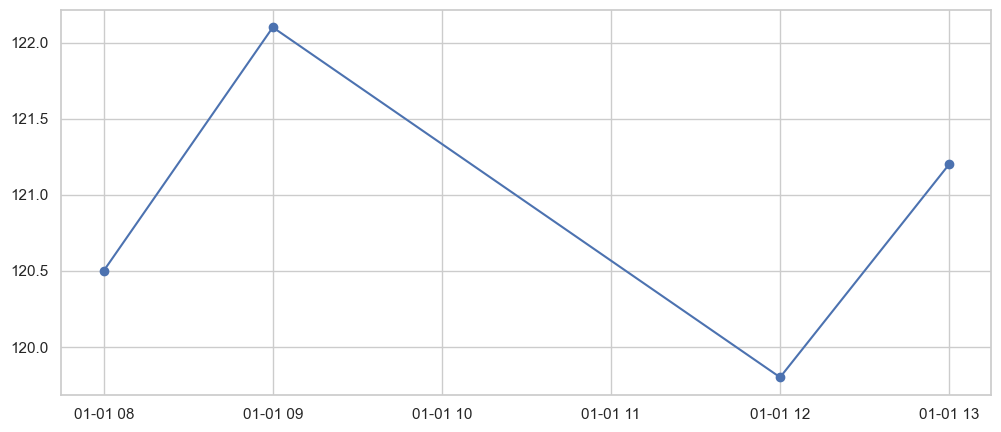

In [20]:
plt.figure(figsize=(12, 5))

# Graficamos los datos "limpios"
plt.plot(df_final['Fecha_Clean'], df_final['Deformacion_Final'],
         marker='o', linestyle='-', color='b', label='Datos Procesados (Interpolados)')

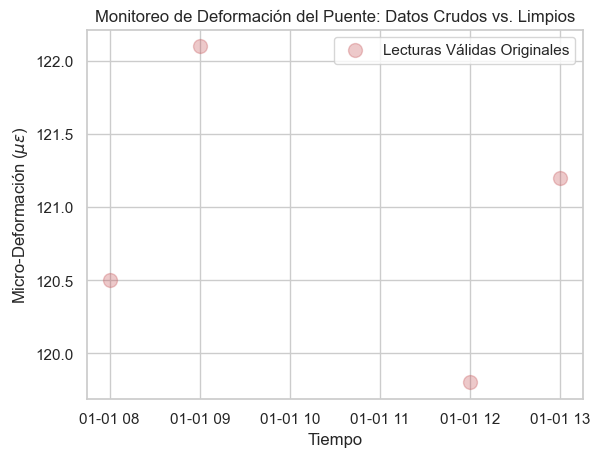

Conclusión: Ahora tenemos una serie continua y lógica lista para el análisis estructural.


In [21]:
# Intentamos graficar dónde había errores (marcándolos en rojo)
# (Solo para fines didácticos, mostramos los puntos válidos originales)
plt.scatter(df_final['Fecha_Clean'], df_final['Deformacion_Clean'],
            color='r', s=100, alpha=0.3, label='Lecturas Válidas Originales')

plt.title("Monitoreo de Deformación del Puente: Datos Crudos vs. Limpios")
plt.xlabel("Tiempo")
plt.ylabel("Micro-Deformación ($\mu\epsilon$)")
plt.legend()
plt.grid(True)
plt.show()

print("Conclusión: Ahora tenemos una serie continua y lógica lista para el análisis estructural.")